Importação das bibliotecas que serão utilizadas.

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Importação dataset Survey.

In [47]:
df = pd.read_csv("data2019.csv")

Descrição Projeto

Este projeto analisa os fatores que influenciam a remuneração de desenvolvedores 
de software a partir dos dados do Stack Overflow Developer Survey 2019, 
com mais de 88.000 respondentes de todo o mundo. 

O objetivo é identificar correlações entre salário (ConvertedComp) e variáveis 
como linguagens de programação utilizadas, nível de educação, anos de experiência 
e país de residência, buscando insights sobre o que realmente impacta a 
remuneração no mercado de tecnologia.

Pré visualização dos dados não limpos.

In [48]:
df.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,1,I am a student who is learning to code,Yes,Never,The quality of OSS and closed source software ...,"Not employed, and not looking for work",United Kingdom,No,Primary/elementary school,NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,14.00,Man,No,Straight / Heterosexual,NaN,No,Appropriate in length,Neither easy nor difficult
1,2,I am a student who is learning to code,No,Less than once per year,The quality of OSS and closed source software ...,"Not employed, but looking for work",Bosnia and Herzegovina,"Yes, full-time","Secondary school (e.g. American high school, G...",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,19.00,Man,No,Straight / Heterosexual,NaN,No,Appropriate in length,Neither easy nor difficult
2,3,"I am not primarily a developer, but I write co...",Yes,Never,The quality of OSS and closed source software ...,Employed full-time,Thailand,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)",Web development or web design,...,Just as welcome now as I felt last year,Tech meetups or events in your area;Courses on...,28.00,Man,No,Straight / Heterosexual,NaN,Yes,Appropriate in length,Neither easy nor difficult
3,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.00,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
4,5,I am a developer by profession,Yes,Once a month or more often,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,Ukraine,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech meetups or events in your area;Courses on...,30.00,Man,No,Straight / Heterosexual,White or of European descent;Multiracial,No,Appropriate in length,Easy


Exploração inicial para limpeza

Número de linhas e colunas

In [49]:
df.shape

(88883, 85)

Tipos de cada coluna

In [50]:
df.dtypes

Respondent      int64
MainBranch        str
Hobbyist          str
OpenSourcer       str
OpenSource        str
                ...  
Sexuality         str
Ethnicity         str
Dependents        str
SurveyLength      str
SurveyEase        str
Length: 85, dtype: object

Contagem de nulos por coluna

In [51]:
df.isnull().sum()

Respondent          0
MainBranch        552
Hobbyist            0
OpenSourcer         0
OpenSource       2041
                ...  
Sexuality       12736
Ethnicity       12215
Dependents       5824
SurveyLength     1899
SurveyEase       1802
Length: 85, dtype: int64

Contagem de duplicatas

In [52]:
df.duplicated().sum()

np.int64(0)

Distribuição do salário

Tivemos problemas com o describe aqui abaixo pois tava retornando o valor em notação científica, então usaremos essa lambda para formatar direitinho!

In [53]:
pd.set_option("display.float_format", lambda x: f'{x:,.2f}')

In [54]:
df['ConvertedComp'].describe()

count      55,823.00
mean      127,110.74
std       284,152.30
min             0.00
25%        25,777.50
50%        57,287.00
75%       100,000.00
max     2,000,000.00
Name: ConvertedComp, dtype: float64

Limpeza

Começaremos limpandos os nulos, verificarei novamentes os nulos nas colunas que vou usar, porque como o dropna, remove a linha inteira onde tem Nan ou nulo, não queremos perder amostra limpando sem filtro.

In [55]:
cols = ['ConvertedComp', 'Country', 'EdLevel', 'YearsCodePro', 'LanguageWorkedWith']
df[cols].isnull().sum()

ConvertedComp         33060
Country                 132
EdLevel                2493
YearsCodePro          14552
LanguageWorkedWith     1314
dtype: int64

Comando pra tirar nulos especificando o filtro que fiz das colunas e já verificando quantos ficaram.

In [56]:
df.dropna(subset=cols).shape

(54642, 85)

Atualizando pra ficar permanente.

In [57]:
df = df.dropna(subset=cols)

Verificando novamente se tem nulos.

In [58]:
df[cols].isnull().sum()

ConvertedComp         0
Country               0
EdLevel               0
YearsCodePro          0
LanguageWorkedWith    0
dtype: int64

Remoção de Outliers, usaremos o IQR, pra verificar o upper e o lower limit e depois visualizaremos os dados num boxplot

O uso do IQR é pelo fato de salário ter uma distribuição assimétrica e ter dados que tem outliers severos que distoceriam a nossa média.

In [59]:
Q1 = df["ConvertedComp"].quantile(0.25)
Q3 = df["ConvertedComp"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Colocaremos esses dados num boxplot pra melhor visualização.

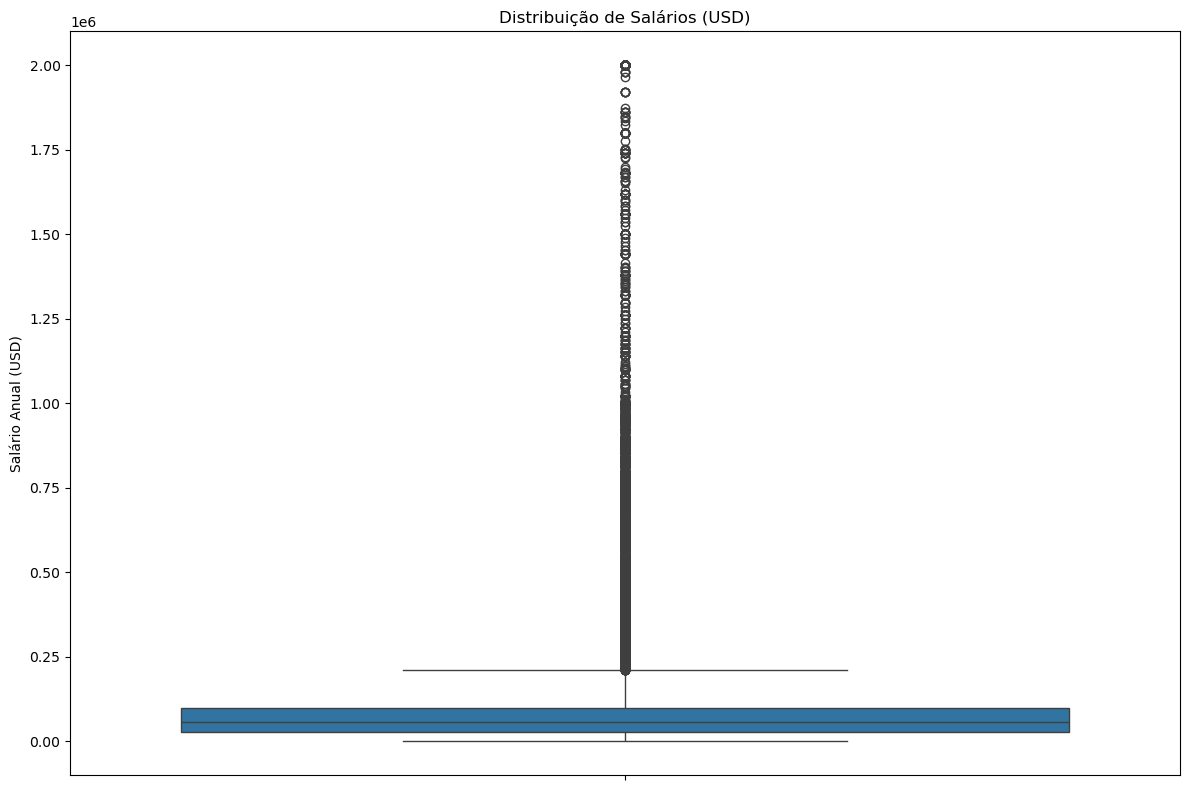

In [60]:
sns.boxplot(y=df['ConvertedComp'])
plt.title('Distribuição de Salários (USD)')
plt.ylabel('Salário Anual (USD)')
plt.tight_layout()
plt.show()

Verificando nosso lower e upper

In [61]:
print(f"IQR: {IQR:,.2f}")
print(f"Lower: {lower:,.2f}")
print(f"Upper: {upper:,.2f}")

IQR: 73,876.00
Lower: -84,690.00
Upper: 210,814.00


Filtrando o dataset removendo outliers, com o & combinando onde apenas as duas forem true.

In [62]:
df = df[(df['ConvertedComp'] >= lower) & (df['ConvertedComp'] <= upper)]

Após análise verificamos que não precisará faz mais filtros para remover outliers porque são categóricas, ou tem limites como o de YearsCode, que tem "More than 50 years" e "Less than 1 year", que por sinal precisaremos filtrar, usaremos 0 pra menos que 1 anos, e 51 pra mais que 50 anos, além de converter sting para numeric, tudo isso nos comandos abaixo.

In [63]:
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'])

Estado final para análise.

In [64]:
df[cols].isnull().sum()

ConvertedComp         0
Country               0
EdLevel               0
YearsCodePro          0
LanguageWorkedWith    0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df['ConvertedComp'].describe()

count    50,155.00
mean     60,541.72
std      45,642.31
min           0.00
25%      23,376.00
50%      52,000.00
75%      85,931.00
max     210,120.00
Name: ConvertedComp, dtype: float64

In [67]:
df['YearsCodePro'].describe()

count   50,155.00
mean         7.86
std          7.15
min          0.00
25%          3.00
50%          5.00
75%         10.00
max         51.00
Name: YearsCodePro, dtype: float64

## Começando análise

## O que realmente determina quanto um desenvolvedor ganha?

A seguir, exploraremos como diferentes fatores, linguagem de programação, 
experiência, nível de educação e país, se relacionam com a remuneração 
de desenvolvedores ao redor do mundo, isso num ano pré pandemia como 2019.

## País

Primeiro começaremos analisando, o país, onde ele trabalha, mora, se desenvolve. o país diz muito sobre o contexto econômico que ele se encontra então achamos um bom ponto de partida pra começar a se trabalhar nossos dados. 

Estamos vendo os Top 10 países por salário mediano - usando mediana, por causa da assimetria de salários mesmo após a remoção de outliers

## Agrupa o dataset por país
## Remove países com menos de 100 respondentes para evitar distorção
## Calcula a mediana salarial por país, ordena e exibe o top 10

In [68]:
country_grp = df.groupby("Country")
df_filtrado = country_grp.filter(lambda x: len(x) >= 100)

In [69]:
top10_paises = df_filtrado.groupby("Country")["ConvertedComp"].median().sort_values(ascending=False).head(10)
top10_paises

Country
United States    100,000.00
Switzerland       90,417.00
Israel            89,076.00
Denmark           82,860.00
Norway            77,022.00
Australia         72,530.00
Ireland           69,891.00
Canada            64,888.00
United Kingdom    60,190.00
Germany           60,037.00
Name: ConvertedComp, dtype: float64

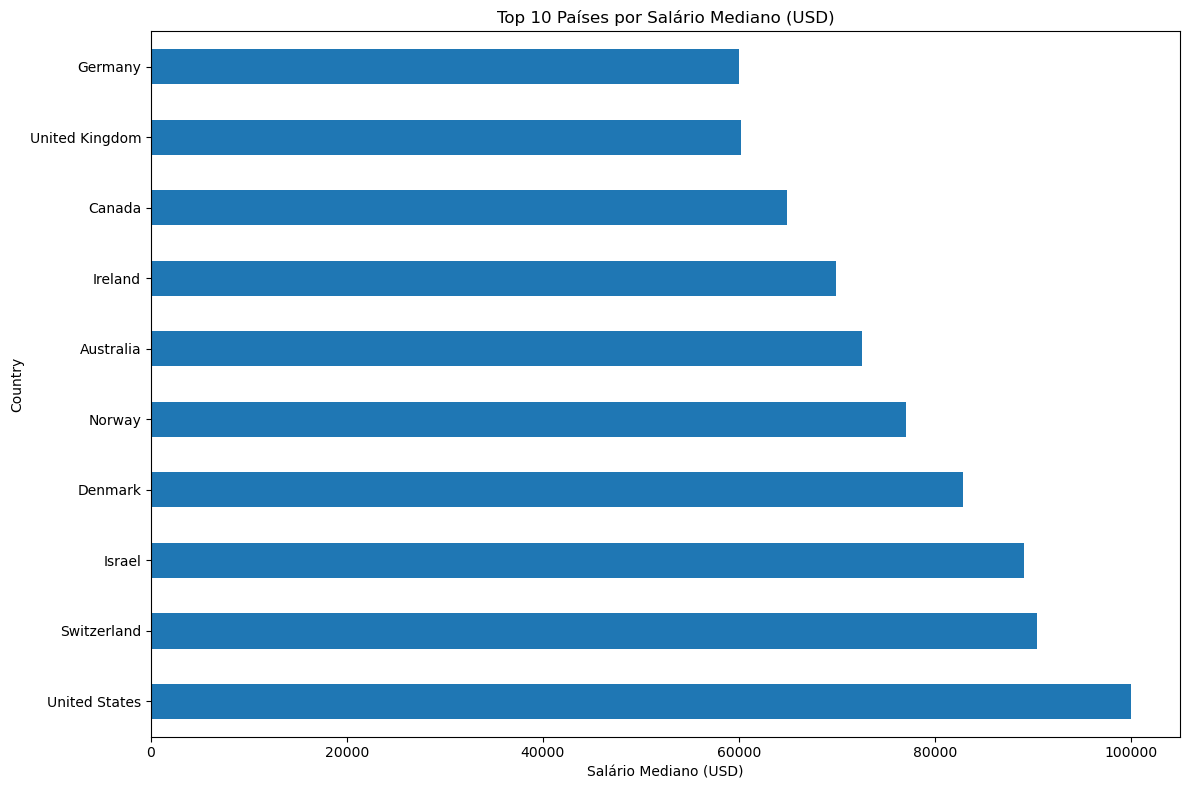

In [70]:
top10_paises.plot(kind="barh")
plt.title("Top 10 Países por Salário Mediano (USD)")
plt.xlabel("Salário Mediano (USD)")
plt.tight_layout()
plt.show()

Algo que podemos ver claramente é que nosso top 10 apresenta países desenvolvidos, os Estados Unidos por exemplo tem o maior ecossistema de startups e bigtechs do mundo, Suíça tem custo de vida altíssimo o que reflete num salário proporcional aos custos, Israel temos o Silicon Wadi similar ao Vale do Silício, Austrália, Canadá, Reino Unido, Irlanda, países anglófonos com mercados de tecnologia ativos e proximidade cultural/linguística com o mercado americano. o que fazem refletir num salário mediano bem alto, mais ou menos 60% acima da média global.


## Nível de Educação

Seguindo para o nível de educação que tem uma forte relação com o quanto ganha um desenvolvedor, vamos fazer uma análise mais profunda sobre. ainda mais com muitas falas hoje em dia que para aprender a ser um desenvolvedor não precisa estudar na faculdade e dá pra aprender em casa
 
 
## Agrupa o dataset por nível de educação
## Remove níveis com menos de 100 respondentes para evitar distorção
## Calcula a mediana salarial por nível de educação, ordena e exibe
## plt.rcParams['figure.figsize'] = (12, 8), O matplotlib tava reclamando dos nomes muito grandes.

In [71]:
edlevel_grp = df.groupby("EdLevel")
df_filtrado1 = edlevel_grp.filter(lambda x: len(x) >= 100)

In [72]:
top9_edlevel = df_filtrado1.groupby("EdLevel")["ConvertedComp"].median().sort_values(ascending=False).head(10)
top9_edlevel

EdLevel
Other doctoral degree (Ph.D, Ed.D., etc.)                                            72,235.00
Master’s degree (MA, MS, M.Eng., MBA, etc.)                                          54,516.00
Bachelor’s degree (BA, BS, B.Eng., etc.)                                             53,850.00
Associate degree                                                                     51,750.00
Some college/university study without earning a degree                               48,120.00
I never completed any formal education                                               44,688.00
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)   34,372.00
Primary/elementary school                                                            31,783.00
Professional degree (JD, MD, etc.)                                                   31,416.00
Name: ConvertedComp, dtype: float64

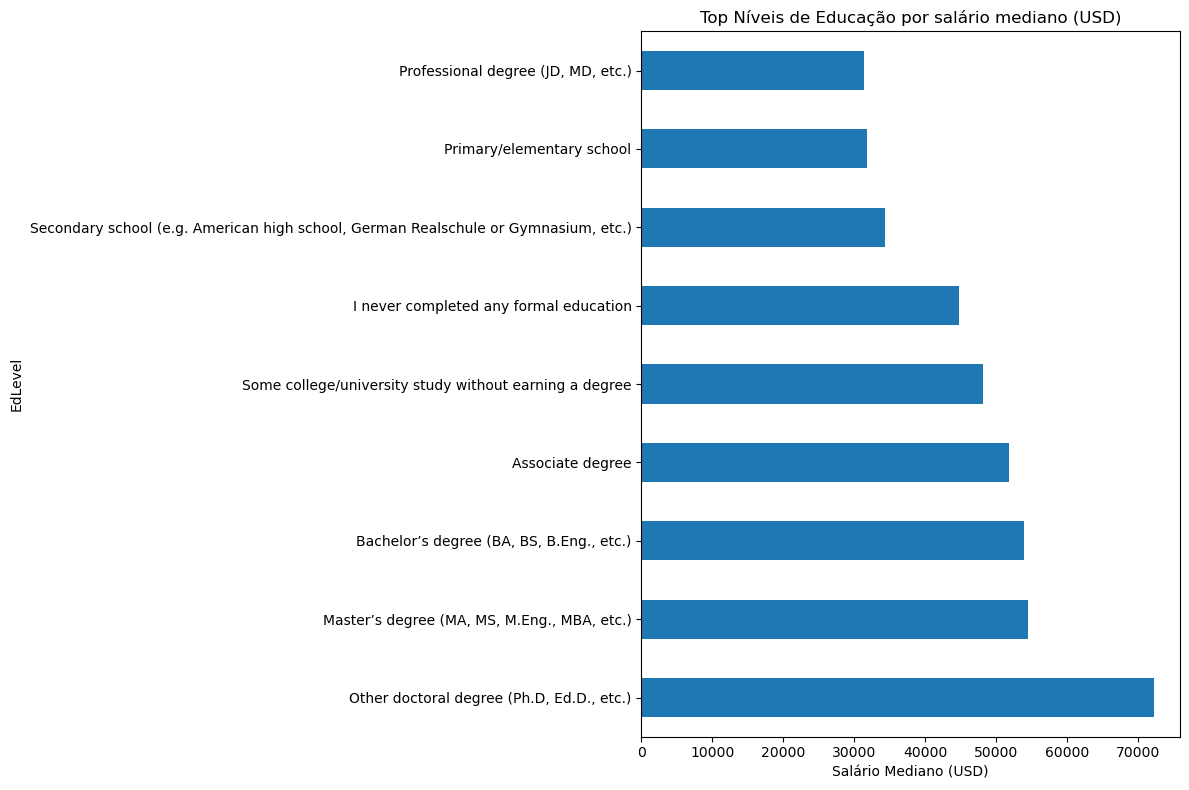

In [73]:
plt.rcParams['figure.figsize'] = (12, 8)
top9_edlevel.plot(kind="barh")
plt.title("Top Níveis de Educação por salário mediano (USD)")
plt.xlabel("Salário Mediano (USD)")
plt.tight_layout()
plt.show()

O nível de educação tem impacto na remuneração, porém menor do que a gente esperava. Doutorado top 1 com 72k USD de mediana, mas a diferença para graduação (53k) é de apenas 19k — menos de 30%. além de que uma surpresa que citamos lá em cima, desenvolvedores sem nenhuma educação formal ganham 44k, apenas 9k abaixo de quem tem graduação. Sugerindo que no mercado de tecnologia, habilidades práticas e experiência compensam a ausência de diploma.

## Linguagem de Programação

Seguindo nossa escada, ele nasce/mora num país, estuda e, por último, escolhe o que vai seguir na carreira aprendendo sua linguagem de programação. Vamos ver o quanto essa escolha impacta no seu salário.

## Explode a coluna LanguageWorkedWith pois cada respondente pode usar múltiplas linguagens separadas por ";". Sem isso, o groupby agruparia pela combinação inteira de linguagens em vez de por linguagem individual.
## Agrupa por linguagem e filtra com pelo menos 100 respondentes para evitar distorção
## Remove a categoria "Other(s):" que não representa uma linguagem específica
## Calcula a mediana salarial por linguagem, ordena e exibe o top 10

In [78]:
df_lang = df.assign(LanguageWorkedWith=df['LanguageWorkedWith'].str.split(';')).explode('LanguageWorkedWith')

In [79]:
lang_grp = df_lang.groupby("LanguageWorkedWith")
df_filtrado2 = lang_grp.filter(lambda x: len(x) >= 100)

In [80]:
top10_lang = df_filtrado2.groupby("LanguageWorkedWith")["ConvertedComp"].median().sort_values(ascending=False).head(10)
top10_lang

LanguageWorkedWith
Clojure                 75,000.00
Elixir                  71,057.50
Go                      70,000.00
Scala                   69,643.50
F#                      69,123.00
Ruby                    68,745.00
Rust                    65,424.00
Erlang                  65,138.50
WebAssembly             65,000.00
Bash/Shell/PowerShell   63,000.00
Name: ConvertedComp, dtype: float64

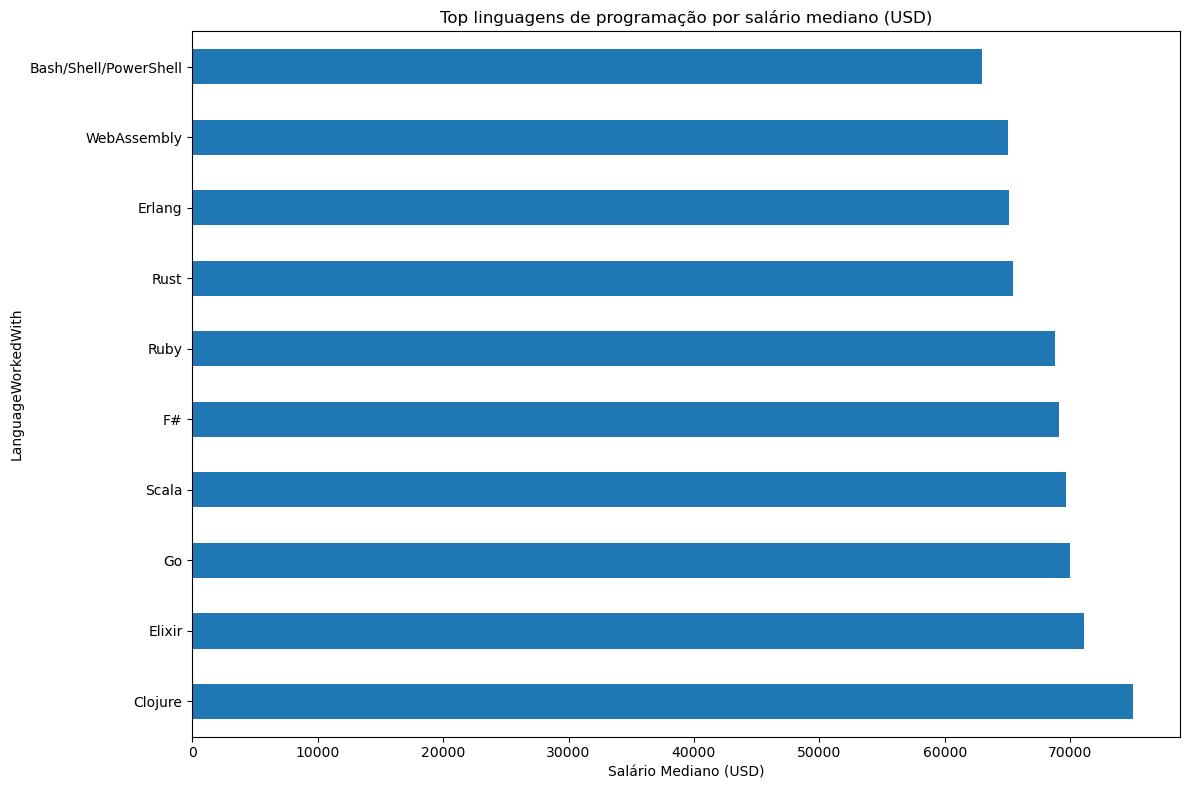

In [83]:
top10_lang.plot(kind="barh")
plt.title("Top linguagens de programação por salário mediano (USD)")
plt.xlabel("Salário Mediano (USD)")
plt.tight_layout()
plt.show()

Linguagens de nicho como Clojure, Elixir e Go lideram o ranking, enquanto Java e PHP ficam na base. Vale destacar que isso não significa que aprender Clojure vai te fazer ganhar mais, quem usa essas linguagens tende a trabalhar em empresas especializadas que pagam bem. É uma correlação, não causalidade. Python aparece na 13ª posição com 57k, reflexo da sua popularidade em contextos variados.

## Anos de experiência

Fechando nossa escada com o último degrau: a experiência. Depois de país, educação e linguagem, quanto tempo de prática realmente pesa no salário?

## Agrupa o dataset por anos de experiência profissional
## Remove grupos com menos de 100 respondentes para evitar distorção
## Calcula a mediana salarial por anos de experiência, ordena e exibe o top 10

In [85]:
yearscode_grp = df.groupby("YearsCodePro")
df_filtrado3 = yearscode_grp.filter(lambda x: len(x) >= 100)

In [86]:
top10_yearscode = df_filtrado3.groupby("YearsCodePro")["ConvertedComp"].median().sort_values(ascending=False).head(10)
top10_yearscode

YearsCodePro
26   110,000.00
35   107,397.50
32   101,542.00
23   100,000.00
27   100,000.00
25    97,957.50
30    97,389.00
24    95,211.50
28    94,246.00
22    91,660.00
Name: ConvertedComp, dtype: float64

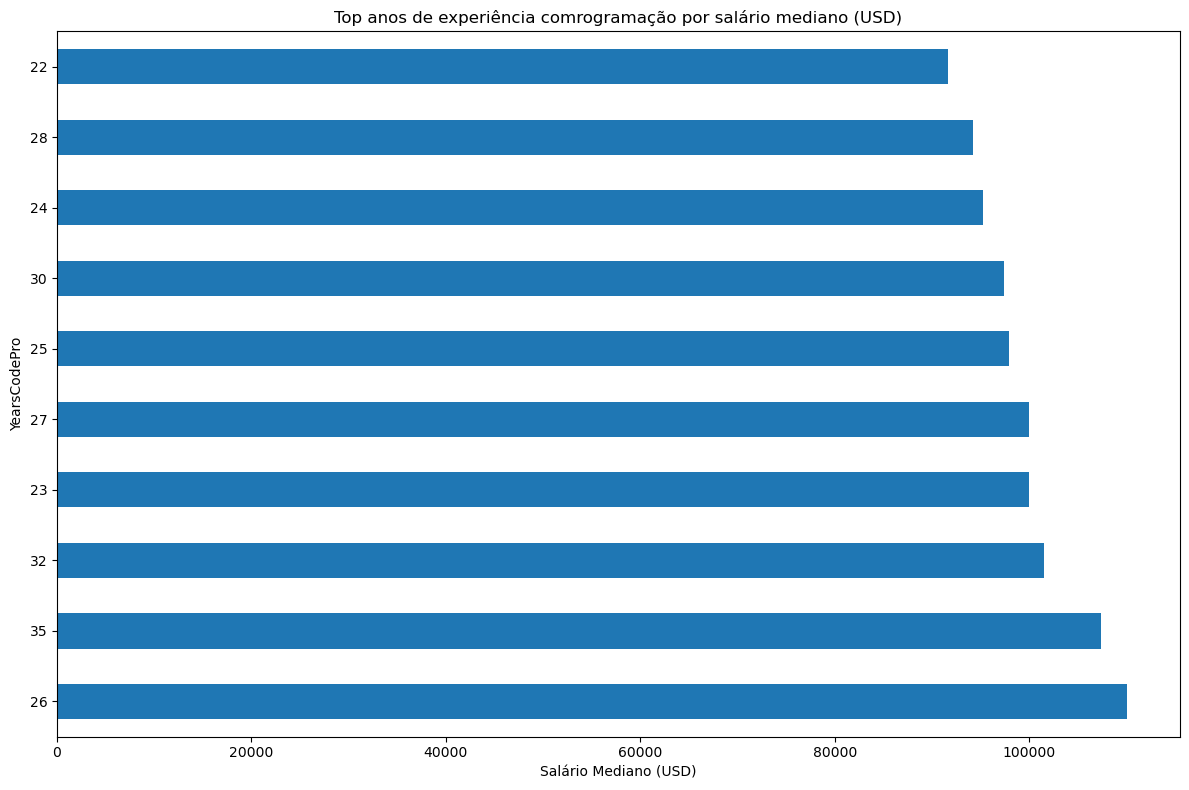

In [87]:
top10_yearscode.plot(kind="barh")
plt.title("Top anos de experiência com programação por salário mediano (USD)")
plt.xlabel("Salário Mediano (USD)")
plt.tight_layout()
plt.show()

Os dados confirmam que experiência importa, os top salários estão todos acima de 22 anos de prática. Porém, o ganho não é linear, a diferença entre 22 e 35 anos é de apenas 20k USD. Isso sugere que após certo nível de senioridade, outros fatores como país e linguagem passam a pesar mais que os anos extras de experiência.